In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"

In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,-0.188 – 0.969 sec
Baseline,off


Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


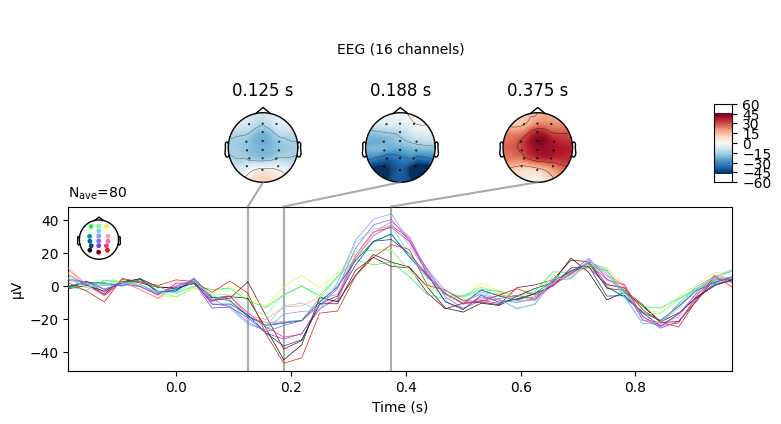

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
contrast.apply_baseline((-0.2,0))
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')



X_train = epochs_train.get_data().astype(np.float32)
y_train = labels_train=='Target'
X_test = epochs_test.get_data().astype(np.float32)
y_test = labels_test=='Target'

scaler = Scaler(with_mean=True, scalings='mean')
X_train = tl.tensor(scaler.fit_transform(X_train))
X_test = tl.tensor(scaler.transform(X_test))

In [8]:
import cupy
from hoda.hoda import shrink, oas
from hoda.tenalg import force_toeplitz

hoda = HODA(
    max_iter=128,
    rank=None,
    explain=1,
    tol=1e-6,
    init ='mlsvd',
    verbose=True,
    shrinkage=('oas','oas'),
    toeplitz=(1,),
    solver='ratio_svd',
    keep_train_info=True,
)
hoda.fit(X_train,y_train)

/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/tensorly/backend/core.py:1106: UserWarning: In partial_svd: converting to NumPy. Check SVD_FUNS for available alternatives if you want to avoid this.
  warnings.warn('In partial_svd: converting to NumPy.'


  0%|          | 0/128 [00:00<?, ?it/s]

Fit tucker model of rank [16, 16]


HODA(explain=1, keep_train_info=True, max_iter=128, shrinkage=('oas', 'oas'),
     solver='ratio_svd', toeplitz=(1,), tol=1e-06, verbose=True)

/tmp/ipykernel_108960/677810071.py:6: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[0].set_ylim([0,None])


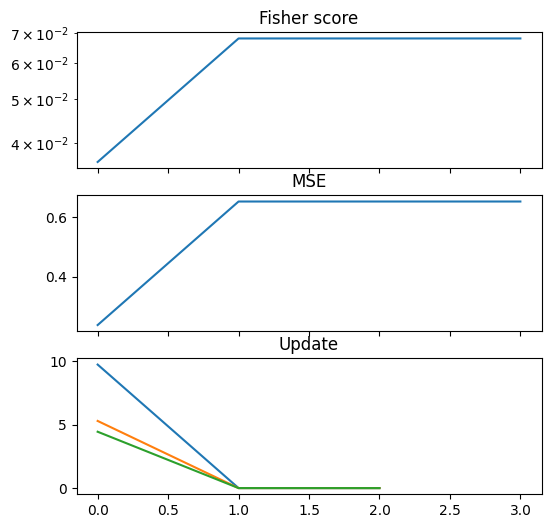

In [9]:
fig, axs = plt.subplots(3,1, sharex=True, figsize=(6,6))

axs[0].set_title('Fisher score')
axs[0].plot(hoda.train_info_["f_score"])
axs[0].semilogy(np.asarray(hoda.train_info_["mode_f_score"]).T)
axs[0].set_ylim([0,None])

axs[1].set_title('MSE')
axs[1].plot(hoda.train_info_["mse"])

axs[2].set_title('Update')
axs[2].plot(hoda.train_info_["update"])
axs[2].plot(np.asarray(hoda.train_info_["mode_update"]).T)


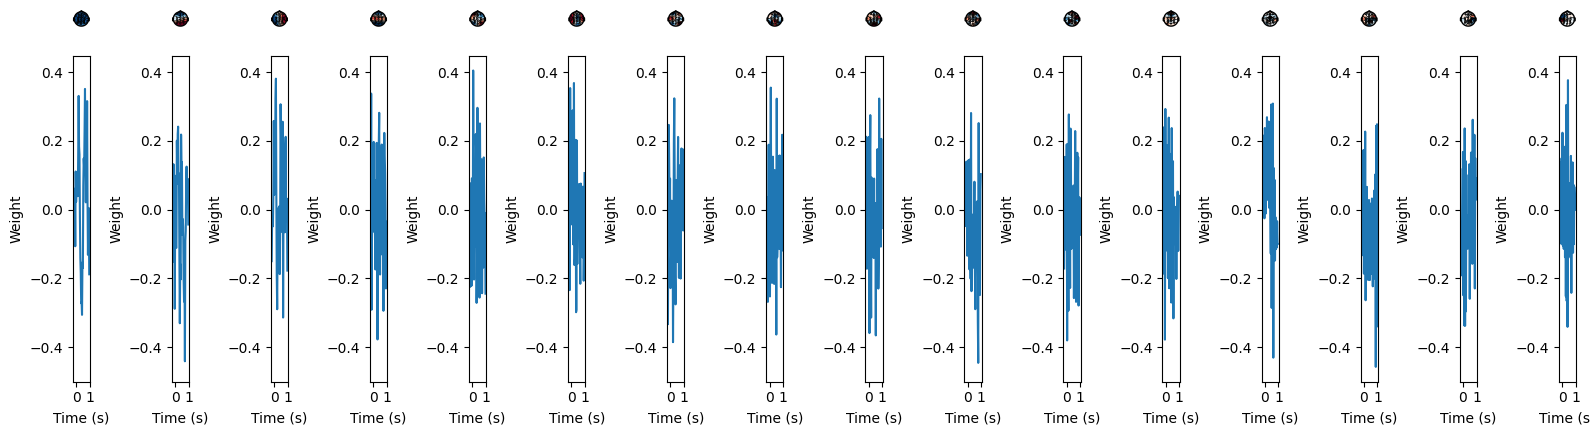

In [10]:
fig, axs = plt.subplots(2,max(hoda.rank_), figsize=(16,6), layout='tight')

for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[0,i], show=False)


for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.scalings_[1][:,i])
    axs[1,i].plot(epochs.times, w)
    axs[1,i].set_xlabel('Time (s)')
    axs[1,i].set_ylabel('Weight')
    axs[1,i].sharey(axs[1,0])


No projector specified for this dataset. Please consider the method self.add_proj.


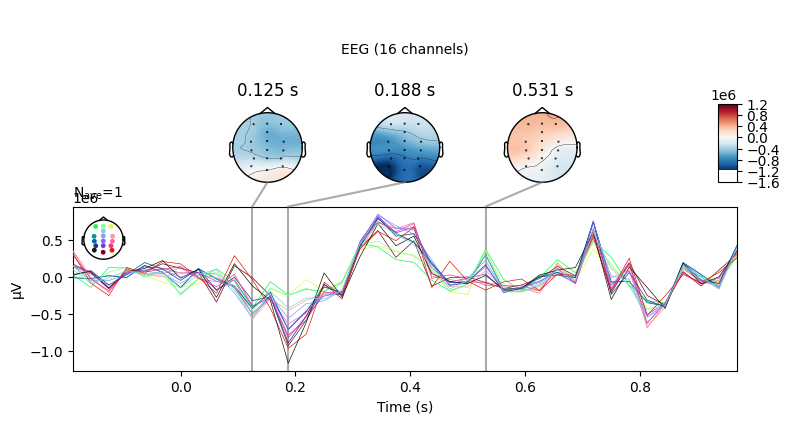

-25.693941285361106


In [11]:
from mne import EvokedArray, combine_evoked

coef = EvokedArray(cupy.asnumpy(hoda.coef_), epochs.info, epochs.tmin)
_ = coef.plot_joint()

print(hoda.intercept_)

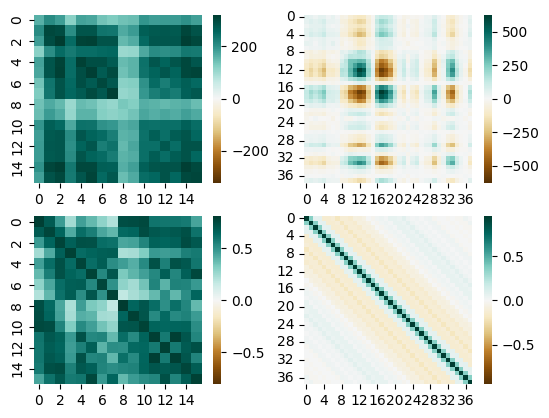

In [12]:
_, axs = plt.subplots(2,2)
for k in range(2):
    scatter_b = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[0,k])    
    axs[0,k].set_aspect('equal')
    scatter_w = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[1,k])    
    axs[1,k].set_aspect('equal')

In [13]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

<AxesSubplot: >

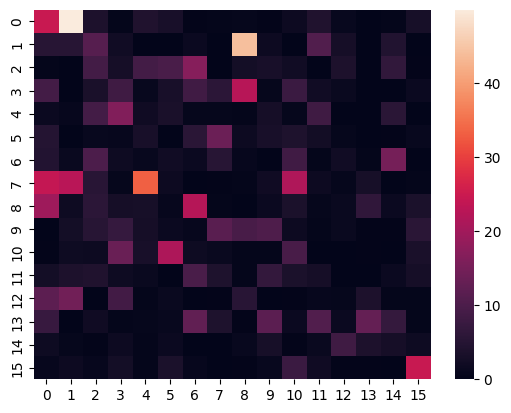

In [14]:
import scipy.stats

samples = []
for c in np.unique(y_train):
    samples.append(Xt_train[y_train==c])
F_stat, p_value = scipy.stats.f_oneway(*samples)
sns.heatmap(F_stat, vmin=0)

In [15]:
n_samples_train = Xt_train.shape[0]
n_samples_test = Xt_test.shape[0]

Xt_train_flat = Xt_train.reshape((n_samples_train,-1))
Xt_test_flat = Xt_test.reshape((n_samples_test,-1))

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC
 
classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train_flat,y_train)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [17]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train_flat)[:,1])

1.0

In [18]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test_flat)[:,1])

0.8900173611111112